C:\Users\catsu\AppData\Local\Temp\ipykernel_8924\3181863715.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment_label", data=absa_df, palette="viridis")


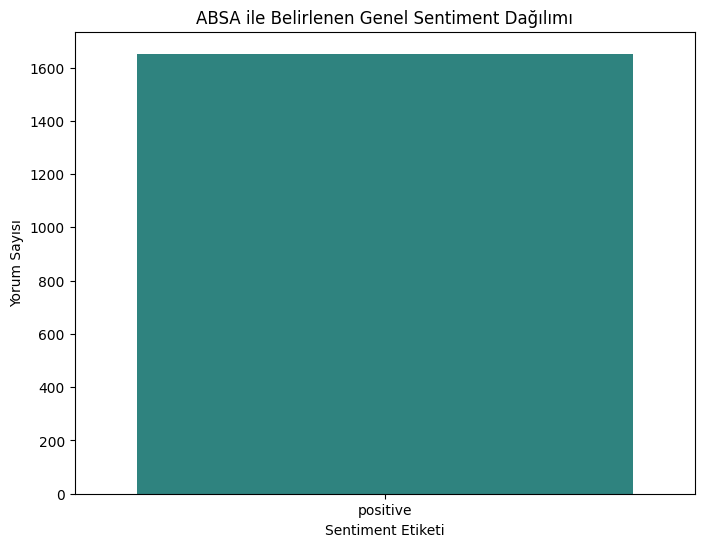

C:\Users\catsu\AppData\Local\Temp\ipykernel_8924\3181863715.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="hotel_name", y="sentiment_score", data=hotel_sentiment, palette="coolwarm")


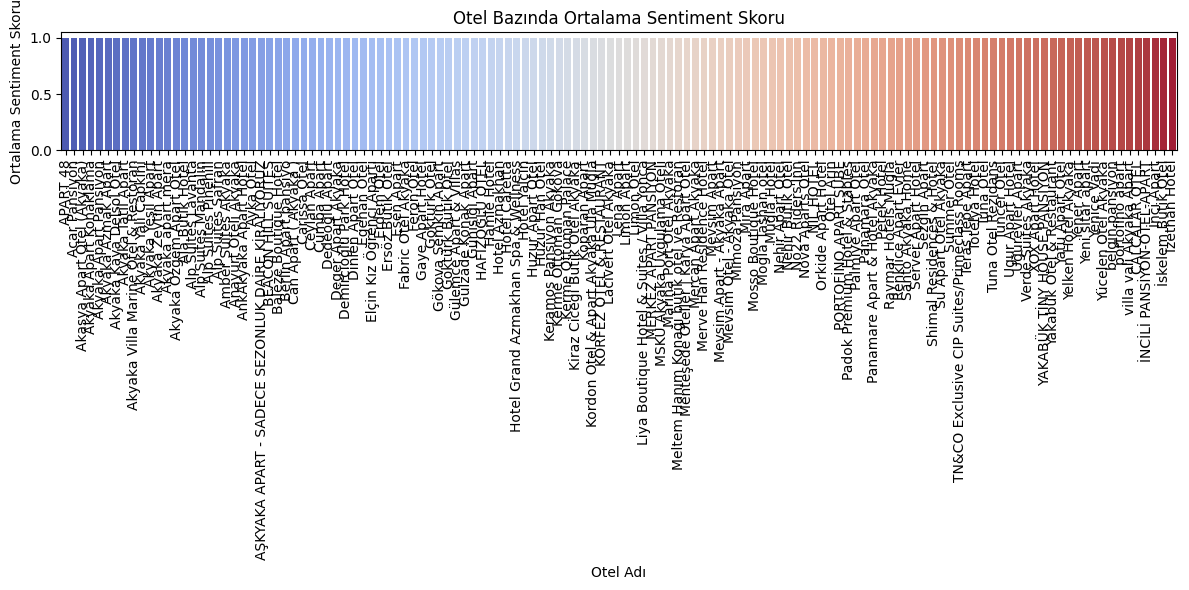

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ABSA sonuçlarını içeren CSV dosyasını oku (dosya yolunu kendi verine göre ayarla)
absa_df = pd.read_csv("absa_sentences.csv", encoding="utf-8-sig")

# 1. Genel sentiment dağılımını görselleştirme (negatif, nötr, pozitif)
plt.figure(figsize=(8, 6))
sns.countplot(x="sentiment_label", data=absa_df, palette="viridis")
plt.title("ABSA ile Belirlenen Genel Sentiment Dağılımı")
plt.xlabel("Sentiment Etiketi")
plt.ylabel("Yorum Sayısı")
plt.show()

# 2. Otel bazında ortalama sentiment skorunu hesaplayıp görselleştirme
# (Sentiment skoru -1: negatif, 0: nötr, +1: pozitif)
hotel_sentiment = absa_df.groupby("hotel_name")["sentiment_score"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x="hotel_name", y="sentiment_score", data=hotel_sentiment, palette="coolwarm")
plt.title("Otel Bazında Ortalama Sentiment Skoru")
plt.xlabel("Otel Adı")
plt.ylabel("Ortalama Sentiment Skoru")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


[INFO] CSV verisi okunuyor...
[INFO] Toplam 1271 yorum okundu.
[INFO] 0 yorum cümlelerine ayrıldı...
[INFO] 100 yorum cümlelerine ayrıldı...
[INFO] 200 yorum cümlelerine ayrıldı...
[INFO] 300 yorum cümlelerine ayrıldı...
[INFO] 400 yorum cümlelerine ayrıldı...
[INFO] 500 yorum cümlelerine ayrıldı...
[INFO] 600 yorum cümlelerine ayrıldı...
[INFO] 700 yorum cümlelerine ayrıldı...
[INFO] 800 yorum cümlelerine ayrıldı...
[INFO] 900 yorum cümlelerine ayrıldı...
[INFO] 1000 yorum cümlelerine ayrıldı...
[INFO] 1100 yorum cümlelerine ayrıldı...
[INFO] 1200 yorum cümlelerine ayrıldı...
[INFO] Toplam 1271 cümle elde edildi.

[INFO] Global LDA eğitiliyor (cümle bazlı)...

[find_optimal_lda] Tüm veride topic sayısı aranıyor: 2..10 arası
   2 topics => coherence=0.3604
   3 topics => coherence=0.4039
   4 topics => coherence=0.3936
   5 topics => coherence=0.3905
   6 topics => coherence=0.3770
   7 topics => coherence=0.3763
   8 topics => coherence=0.3644
   9 topics => coherence=0.3624

[find_op

C:\Users\catsu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_pca.py:559: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
C:\Users\catsu\AppData\Local\Temp\ipykernel_8924\3305833535.py:224: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment_label", data=absa_df, palette="viridis")


[INFO] PCA sonuçları: 131 otel için özet çıkarıldı.

[INFO] CSV dosyaları oluşturuluyor...
[INFO] 'absa_sentences.csv', 'hotel_pca_summary.csv' ve 'hotel_topic_avg_sentiment.csv' kaydedildi.

***** Tüm işlemler tamamlandı! *****


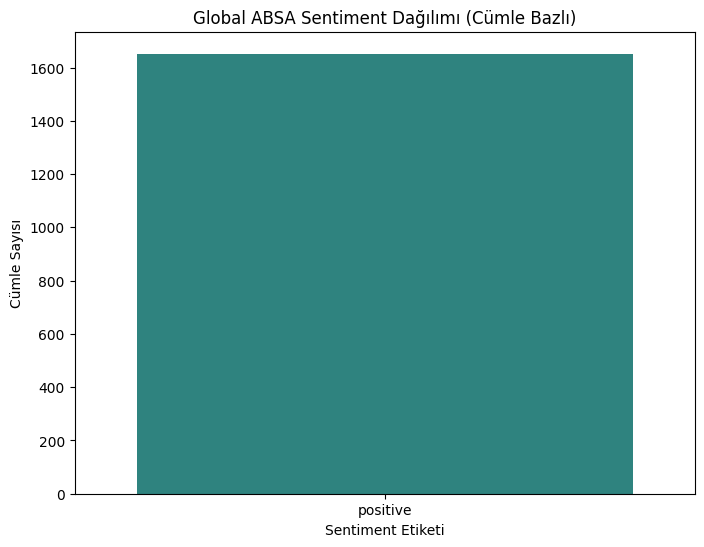

C:\Users\catsu\AppData\Local\Temp\ipykernel_8924\3305833535.py:233: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="hotel_name", y="sentiment_score", data=hotel_sentiment, palette="coolwarm")


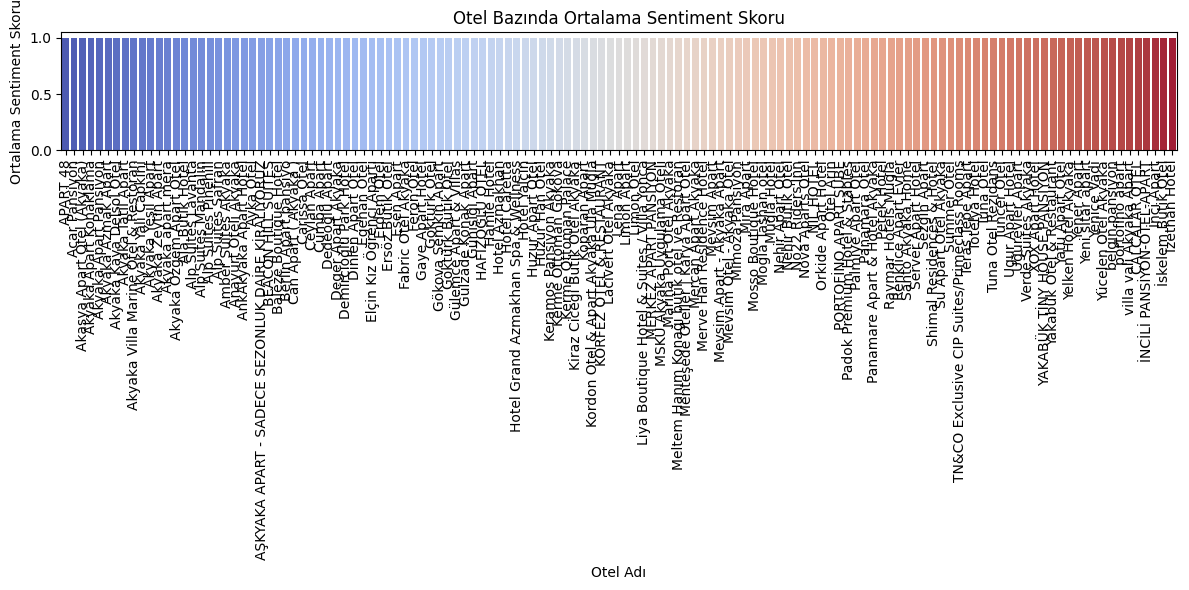

In [5]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import re
import numpy as np
import pandas as pd
import nltk
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK verilerini indir (gerekli tokenizasyon, POS tag vb.)
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
from nltk.tokenize import sent_tokenize, word_tokenize

# Gensim ve Transformers kütüphaneleri
from gensim.models import LdaModel, CoherenceModel
from gensim.corpora.dictionary import Dictionary
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Sklearn modülleri
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

#######################################
# ABSA Model Ayarları (İngilizce için eğitilmiş)
#######################################
absa_model_name = "yangheng/deberta-v3-base-absa-v1.1"
absa_tokenizer = AutoTokenizer.from_pretrained(absa_model_name, use_fast=False)
absa_model = AutoModelForSequenceClassification.from_pretrained(absa_model_name)
absa_model.eval()

def score_to_label(score):
    if score < 0:
        return "negative"
    elif score == 0:
        return "neutral"
    else:
        return "positive"

def absa_sentiment(text, aspect):
    """
    Belirtilen metin ve aspect için ABSA modelinden duygu analizi yapar.
    Model çıktısına göre:
      - 1-2 star: -1 (negative)
      - 3 star: 0 (neutral)
      - 4-5 star: +1 (positive)
    """
    inputs = absa_tokenizer(text, aspect, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = absa_model(**inputs)
    probs = F.softmax(outputs.logits[0], dim=-1)
    label_id = torch.argmax(probs).item()
    label = absa_model.config.id2label[label_id]
    if label.lower().startswith("1 star") or label.lower().startswith("2 star"):
        score = -1
    elif label.lower().startswith("3 star"):
        score = 0
    else:
        score = 1
    return score, score_to_label(score)

#######################################
# Global LDA Fonksiyonları
#######################################
def find_optimal_lda(tokenized_texts, start=2, limit=10, step=1, passes=10):
    dictionary = Dictionary(tokenized_texts)
    corpus = [dictionary.doc2bow(t) for t in tokenized_texts]
    
    best_coherence = -999
    best_model = None
    best_num_topics = None
    
    print(f"\n[find_optimal_lda] Tüm veride topic sayısı aranıyor: {start}..{limit} arası")
    for num_topics in range(start, limit, step):
        tmp_model = LdaModel(corpus=corpus,
                             id2word=dictionary,
                             num_topics=num_topics,
                             passes=passes,
                             random_state=42)
        cm = CoherenceModel(model=tmp_model,
                            texts=tokenized_texts,
                            dictionary=dictionary,
                            coherence='c_v')
        coh_val = cm.get_coherence()
        print(f"   {num_topics} topics => coherence={coh_val:.4f}")
        if coh_val > best_coherence:
            best_coherence = coh_val
            best_model = tmp_model
            best_num_topics = num_topics
    
    print(f"\n[find_optimal_lda] En iyi topic sayısı={best_num_topics}, coherence={best_coherence:.4f}")
    return best_num_topics, best_model, dictionary, corpus

def get_topic_keywords(lda_model, num_words=8):
    topic_keywords = {}
    for t_id, kw_list in lda_model.show_topics(num_topics=-1, num_words=num_words, formatted=False):
        topic_keywords[t_id] = [term for term, _ in kw_list]
    return topic_keywords

def get_dominant_topics(lda_model, bow, threshold=0.2):
    topic_weights = lda_model.get_document_topics(bow)
    return [t_id for t_id, w in topic_weights if w >= threshold]

#######################################
# Otel Bazında PCA Fonksiyonu
#######################################
def pca_for_hotel(hotel_reviews):
    if len(hotel_reviews) < 2:
        return (0.0, 0.0), (0.0, 0.0)
    vectorizer = TfidfVectorizer(token_pattern=r'\S+')
    X = vectorizer.fit_transform(hotel_reviews)
    if X.shape[0] < 2:
        return (0.0, 0.0), (0.0, 0.0)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X.toarray())
    avg_pca = np.mean(X_pca, axis=0)
    var_ratio = pca.explained_variance_ratio_
    return avg_pca, var_ratio

#######################################
# Main Kod Bloğu
#######################################
if __name__ == "__main__":
    # 1. CSV'den Veri Okuma
    csv_path = "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv"
    print("[INFO] CSV verisi okunuyor...")
    df = pd.read_csv(csv_path, encoding="utf-8")
    df.dropna(subset=["hotel_name", "processed_final_review"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"[INFO] Toplam {df.shape[0]} yorum okundu.")
    
    # 2. Her Yorumu Cümlelere Ayır (Global Corpus Oluşturma)
    all_sentences = []
    sentence_records = []
    for idx, row in df.iterrows():
        hotel = row["hotel_name"]
        full_text = row["processed_final_review"]
        sentences = sent_tokenize(full_text)
        for sent in sentences:
            tokens = word_tokenize(sent.lower())
            if tokens:  # boş cümleleri atla
                all_sentences.append(tokens)
                sentence_records.append({
                    "hotel_name": hotel,
                    "sentence": sent
                })
        if idx % 100 == 0:
            print(f"[INFO] {idx} yorum cümlelerine ayrıldı...")
    sentences_df = pd.DataFrame(sentence_records)
    print(f"[INFO] Toplam {sentences_df.shape[0]} cümle elde edildi.")
    
    # 3. Global LDA Eğitimi (Cümle Bazlı)
    print("\n[INFO] Global LDA eğitiliyor (cümle bazlı)...")
    best_topic_num, lda_model, dictionary, corpus = find_optimal_lda(tokenized_texts=all_sentences, start=2, limit=10, step=1, passes=10)
    print(f"[INFO] Global LDA ile en iyi topic sayısı: {best_topic_num}")
    topic_keywords = get_topic_keywords(lda_model, num_words=8)
    for t_id, words in topic_keywords.items():
        print(f"   Topic {t_id}: {words}")
    
    # 4. Cümle Bazlı ABSA: Her cümle için dominant topic(ler) belirleyip, ABSA uygulama
    results = []
    total_sentences = sentences_df.shape[0]
    for idx, row in sentences_df.iterrows():
        hotel = row["hotel_name"]
        sent = row["sentence"]
        tokens = word_tokenize(sent.lower())
        bow = dictionary.doc2bow(tokens)
        dominant_topics = get_dominant_topics(lda_model, bow, threshold=0.2)
        # Eğer birden fazla topic baskınsa, her biri için ABSA çalıştır
        for t_id in dominant_topics:
            # Aspect olarak, o topic’in keyword’lerini birleştiriyoruz
            aspect = " ".join(topic_keywords.get(t_id, []))
            score, label = absa_sentiment(sent, aspect)
            results.append({
                "hotel_name": hotel,
                "sentence": sent,
                "topic_id": t_id,
                "aspect_keywords": aspect,
                "sentiment_score": score,
                "sentiment_label": label
            })
        if idx % 200 == 0:
            print(f"[INFO] {idx}/{total_sentences} cümle işlendi...")
    absa_df = pd.DataFrame(results)
    print(f"[INFO] ABSA sonuçları elde edildi: {absa_df.shape[0]} satır.")
    
    # 5. Otel Bazında PCA Hesaplama
    print("\n[INFO] Otel bazında PCA hesaplanıyor...")
    pca_records = []
    for hotel in df["hotel_name"].unique():
        hotel_reviews = df[df["hotel_name"] == hotel]["processed_final_review"].tolist()
        avg_pca, var_ratio = pca_for_hotel(hotel_reviews)
        pca_records.append({
            "hotel_name": hotel,
            "pca_pc1": float(avg_pca[0]),
            "pca_pc2": float(avg_pca[1]),
            "var_ratio_pc1": float(var_ratio[0]) if len(var_ratio)>0 else 0.0,
            "var_ratio_pc2": float(var_ratio[1]) if len(var_ratio)>1 else 0.0
        })
    pca_df = pd.DataFrame(pca_records)
    print(f"[INFO] PCA sonuçları: {pca_df.shape[0]} otel için özet çıkarıldı.")
    
    # 6. Otel & Topic Bazında Ortalama Sentiment Pivot Tablosu
    pivot_df = absa_df.groupby(["hotel_name", "topic_id"]).agg({"sentiment_score": "mean"}).reset_index()
    pivot_df["avg_sentiment_label"] = pivot_df["sentiment_score"].apply(score_to_label)
    
    # 7. CSV Çıktılarının Oluşturulması
    print("\n[INFO] CSV dosyaları oluşturuluyor...")
    absa_df.to_csv("absa_sentences.csv", index=False, encoding="utf-8-sig")
    pca_df.to_csv("hotel_pca_summary.csv", index=False, encoding="utf-8-sig")
    pivot_df.to_csv("hotel_topic_avg_sentiment.csv", index=False, encoding="utf-8-sig")
    print("[INFO] 'absa_sentences.csv', 'hotel_pca_summary.csv' ve 'hotel_topic_avg_sentiment.csv' kaydedildi.")
    
    print("\n***** Tüm işlemler tamamlandı! *****")
    
    # Ek: Görselleştirmeler
    # a) Global ABSA Sentiment Dağılımı (Cümle Bazlı)
    plt.figure(figsize=(8, 6))
    sns.countplot(x="sentiment_label", data=absa_df, palette="viridis")
    plt.title("Global ABSA Sentiment Dağılımı (Cümle Bazlı)")
    plt.xlabel("Sentiment Etiketi")
    plt.ylabel("Cümle Sayısı")
    plt.show()
    
    # b) Otel Bazında Ortalama Sentiment Skorları
    hotel_sentiment = absa_df.groupby("hotel_name")["sentiment_score"].mean().reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(x="hotel_name", y="sentiment_score", data=hotel_sentiment, palette="coolwarm")
    plt.title("Otel Bazında Ortalama Sentiment Skoru")
    plt.xlabel("Otel Adı")
    plt.ylabel("Ortalama Sentiment Skoru")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

